In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import interpolate
from scipy.integrate import cumulative_trapezoid
from scipy.integrate import quad
from iminuit import Minuit
from iminuit.cost import UnbinnedNLL
from matplotlib.gridspec import GridSpec


# Step 1

In [2]:
# Set random seed for reproducibility
np.random.seed(4)

In [3]:
#Given nominal values of the parameters
tau_g = 1.5e-6 # seconds - lifetime parameter (τ)
m_g = 20e6 # Hz - sinusoidal oscillations parameter (∆m)
V_g = 0.1 # dimensionless - matter/antimatter asymmetry parameter (V)

# Limits the recorded events to be above the background noise ( t < 0.5e-6 s)
# and below the finite detector acceptance (t < 10e-6 s).

t_min = 0.5e-6 # seconds
t_max = 10e-6 # seconds
n = 10000 # number of events

# Probability Density Function (PDF) of the signal decay.

def pdf(t, tau, m, V):
    return (1 + V * np.sin(m * t)) * np.exp(-t / tau) # unnormalized PDF

#Normalizes the PDF over the interval [t_min, t_max] using trapezoidal integration

def normalization(tau, m, V):
    t_vals = np.linspace(t_min, t_max, n)
    pdf_vals = pdf(t_vals, tau, m, V)
    norm = cumulative_trapezoid(pdf_vals, t_vals, initial=0)[-1] 
    return norm


# Attempted quad integration for normalization 
# but the method although more accurate is much more time intensive

# def normalization(tau, m, V):
#     integral, _ = quad(pdf, t_min, t_max, args=(tau, m, V))
#     return integral

#Applies normalization to the PDF

def normalized_pdf(t, tau, m, V):
    norm = normalization(tau, m, V)
    return pdf(t, tau, m, V) / norm

Two generation methods were attempted, the Box Method and the Inverse Cumulative Method:

The Box Method uses two uniform random number generators to see if the point lies within the normalized pdf through an accept/reject check. Values ($y_{rand}$) are accepted if the like within the pdf and appended until the 10,000 dataset is reached.
* This method is much slower due to the generation of two randomized numbers and is neglected (runtime ~ 16 secs for 100 pseudoexperiments).

The Inverse Cumulative Method uses only one uniform random number generator and two distribution functions to test what values correspond to fraction of the distribution.

1. The CDF (Cumulative Distribution Function): numerically integrates the PDF from $t_{min}$ to each point in the interval. This is then normalized [0,1]

2. The PPF (Percent-Point Function): is the inverse of the CDF. Evaluated using interpolation that for a given probablitiy value, it returns the corersponding decay time.

Once the PPF is calculated, a random number generator shifts through the PPF for the number of desired samples in the dataset (n = 10,000).

* This method is much more desirable for it's runtime ~ 3 secs across 100 pseudoexperiments. 

In [4]:
# Box Method for event generation, much slower due to the generation of two randomized parameters

# def generate_events(n_events, tau, m, V):
#     events = []

#     t_test = np.linspace(t_min, t_max, n)
#     pdf_max = np.max([normalized_pdf(t, tau, m, V) for t in t_test])

#     while len(events) < n_events:
#         t_rand = np.random.uniform(t_min, t_max)
#         y_rand = np.random.uniform(0, pdf_max)
#         if y_rand <= normalized_pdf(t_rand, tau, m, V):
#             events.append(t_rand)

#     return np.array(events)

# events = generate_events(n, tau_g, m_g, V_g)

In [5]:
# Cumulative Distribution Function
def cdf(tau, m, V, t_min, t_max):

    # Creates an array of time values and computes the PDF at those points
    t_vals = np.linspace(t_min, t_max, n)
    pdf_vals = pdf(t_vals, tau, m, V)

    # Computes the CDF using trapezoidal integration
    cdf_vals = cumulative_trapezoid(pdf_vals, t_vals, initial=0)
    cdf_vals = cdf_vals / cdf_vals[-1]  # Normalize CDF

    # Interpolates the CDF at each value within the range to create the PPF
    ppf = interpolate.interp1d(cdf_vals, t_vals,  fill_value=(t_min, t_max))

    return ppf

# Generates events for random uniform values using the PPF
def generate_events(tau, m, V):
    ppf = cdf(tau, m, V, t_min, t_max)
    u = np.random.uniform(0, 1, n)
    events = ppf(u)
    return events

events = generate_events(tau_g, m_g, V_g)

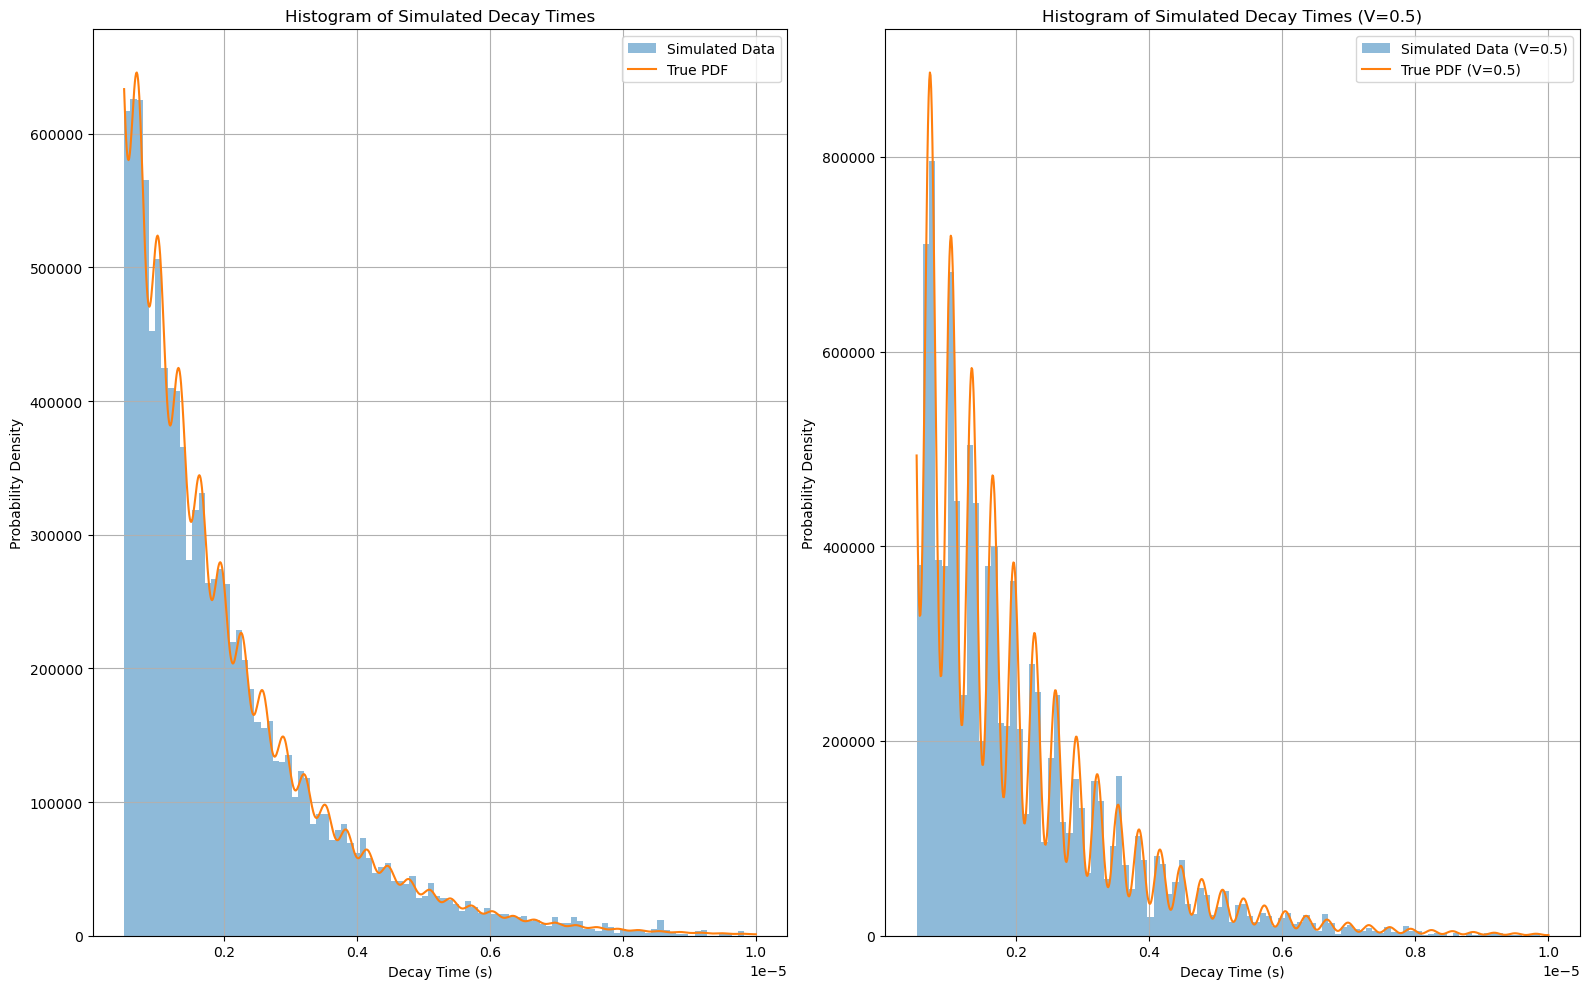

In [6]:
# Plot of a single dataset (10,000 simulations) for proof correct implementation.
# Uses two subplots to show the effect of changing the oscillatory parameter on the distribution of decay times.

plt.figure(figsize=(16, 10))

plt.subplot(1, 2, 1)
plt.hist(events, bins=100, density=True, alpha=0.5, label='Simulated Data')
t_plot = np.linspace(t_min, t_max, 1000)
plt.plot(t_plot, normalized_pdf(t_plot, tau_g, m_g, V_g), label='True PDF')
plt.xlabel('Decay Time (s)')
plt.ylabel('Probability Density')
plt.title('Histogram of Simulated Decay Times')
plt.legend()
plt.grid()

# Changing the asymmetry parameter causes a noticeable oscillatory change as it amplifies the sinusoidal component of the PDF.

plt.subplot(1, 2, 2)
events2 = generate_events(tau_g, m_g, 0.5)
plt.hist(events2, bins=100, density=True, alpha=0.5, label='Simulated Data (V=0.5)')
plt.plot(t_plot, normalized_pdf(t_plot, tau_g, m_g, 0.5), label='True PDF (V=0.5)')
plt.xlabel('Decay Time (s)')
plt.ylabel('Probability Density')
plt.title('Histogram of Simulated Decay Times (V=0.5)')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

Minimizes the normalized pdf across three parameters: the lifetime (τ), sinusoidal oscillation (∆m), and asymmetry parameter (V).
The method uses an Unbinned Negative Log-Likelihood (NLL) as a cost function to calcaulate:

$-\sum(\log(model_{pdf}(t_i, tau, m, V)))$ 
    
for decay values ($t_i$) between the range of [$t_{min}$, $t_{max}$] and the normalized model as the model pdf. We use Unbinned NLL instead of $\chi^{2}$ as we don't lose any information (times) through binned counts. 


In [7]:
nll = UnbinnedNLL(events, normalized_pdf)
min = Minuit(nll, tau_g, m_g, V_g)
# Perform the minimization and calculate the uncertainties
min.migrad()
min.hesse()         

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = -2.483e+05                 │              Nfcn = 61               │
│ EDM = 3.68e-08 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ tau  │ 1.510e-6  │ 0.016e-6  │            │            │         │         │       │
│ 1 │ m    │  20.02e6  │  0.05e6   │            │            │         │         │       │
│ 2 │ V    │   0.099   │   0.014   │            │            │         │         │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌─────┬────────────────────────────────────────────────────┐
│     │              tau                m                V │
├─────┼────────────────────────────────────────────────────┤
│ tau │         2.47e-16 4.19155850226e-6     -9.12200e-12 │
│   m │ 4.19155850226e-6         2.08e+09         -1.87516 │
│   V │     -9.12200e-12         -1.87516         0.000197 │
└─────┴────────────────────────────────────────────────────┘

The result of the minization is a covariance matrix with the minimized cost function (UnbinnedNLL) at a value of ~ -250,000 with each parameter (τ = 1.510e-6, ∆m = 20.02e6, and V = 0.0.99) plugged in. The EDM shows the estimated distance to the true minimum, equated to be very small (3.68e-8) by using gradiant vectors and the covariance matrix. All this was achieved through 61 (Nfcn) iterated evaluations of the cost function with Minuit.

For reference:

The covariance matrix shows the correlation of the different parameters to each one another through the off-diagonal elements. This is calculated using a corerlation coefficient:

$\rho_{xy} = \frac{\sigma^2_{xy}}{\sigma_x\sigma_y}$;

 - $\sigma^2_x$: variance of a paramater, expected value of the squared sampling deviations calcuated as $\frac{1}{n-1} * \Sigma(x_{i} - \bar{x})^2$; where $x_i$ is the value of the parameter at index $i$ of the for loop, $\bar{x}$ is the mean of the sample, and $n$ is the sample size. A $\frac{1}{n-1}$ factor is used to make the sample variance and unbiased estimate of the population variance.
 - $\sigma^2_{xy}$: covariance of two parameters how likely one mismeasured variable includences the other value to be mismeasured. If independent parameters $\sigma^2_{xy} \Rightarrow 0$.

However, Minuit doesn't rely on sample statistics and instead uses the inverse Hessian matrix (H = CoVar $^{-1}$). This approach uses the second partial derivatives of the cost function with each parameter. For diagonal elements:
- $H_{1,1} = \frac{\partial^2 FCN}{\partial \tau^2}$,
- $H_{2,2} = \frac{\partial^2 FCN}{\partial \Delta m^2}$,
- $H_{3,3} = \frac{\partial^2 FCN}{\partial V^2}$

and off-diagonal elements:
$H_{1,2} = \frac{\partial^2 FCN}{\partial \tau  \partial \Delta m }$, $H_{2,3} = \frac{\partial^2 FCN}{\partial V \partial \Delta m}$, etc.

The appraoch of using Hessian statistics rather than sample statistics is more effective in finding minima using the local curvature of the cost function with the second partial derivatives.

The graph plotted below the covariance matrix is the diagnostic plot following the profile of the NLL as a function of one parameter. It is produced with min.migrand() and highlights the evaluations of the NLL as it converges to a minimal value.

Once the distribution is minimized, we save the minimized values of the different parameters and use them as a fit for the distribution, with errors calculated through the Hessian matrix.

In [8]:
# Extract fitted parameters and their uncertainties

tau_fit = min.values['tau']
tau_error = min.errors['tau']
m_fit = min.values['m']
m_error = min.errors['m']
V_fit = min.values['V']
V_error = min.errors['V']

print(f"Fitted tau: {tau_fit:.2e} ± {tau_error:.2e} s")
print(f"Fitted m: {m_fit:.2e} ± {m_error:.2e} Hz")
print(f"Fitted V: {V_fit:.2f} ± {V_error:.2f}")

Fitted tau: 1.51e-06 ± 1.57e-08 s
Fitted m: 2.00e+07 ± 4.56e+04 Hz
Fitted V: 0.10 ± 0.01


A histogram of the distribution is then plotted with two functions following the distribution, one using the given values plugged into the distribution function and one using the minimized values. These two functions follow very close as the minmized values are only a small fraction away from the provided given values.

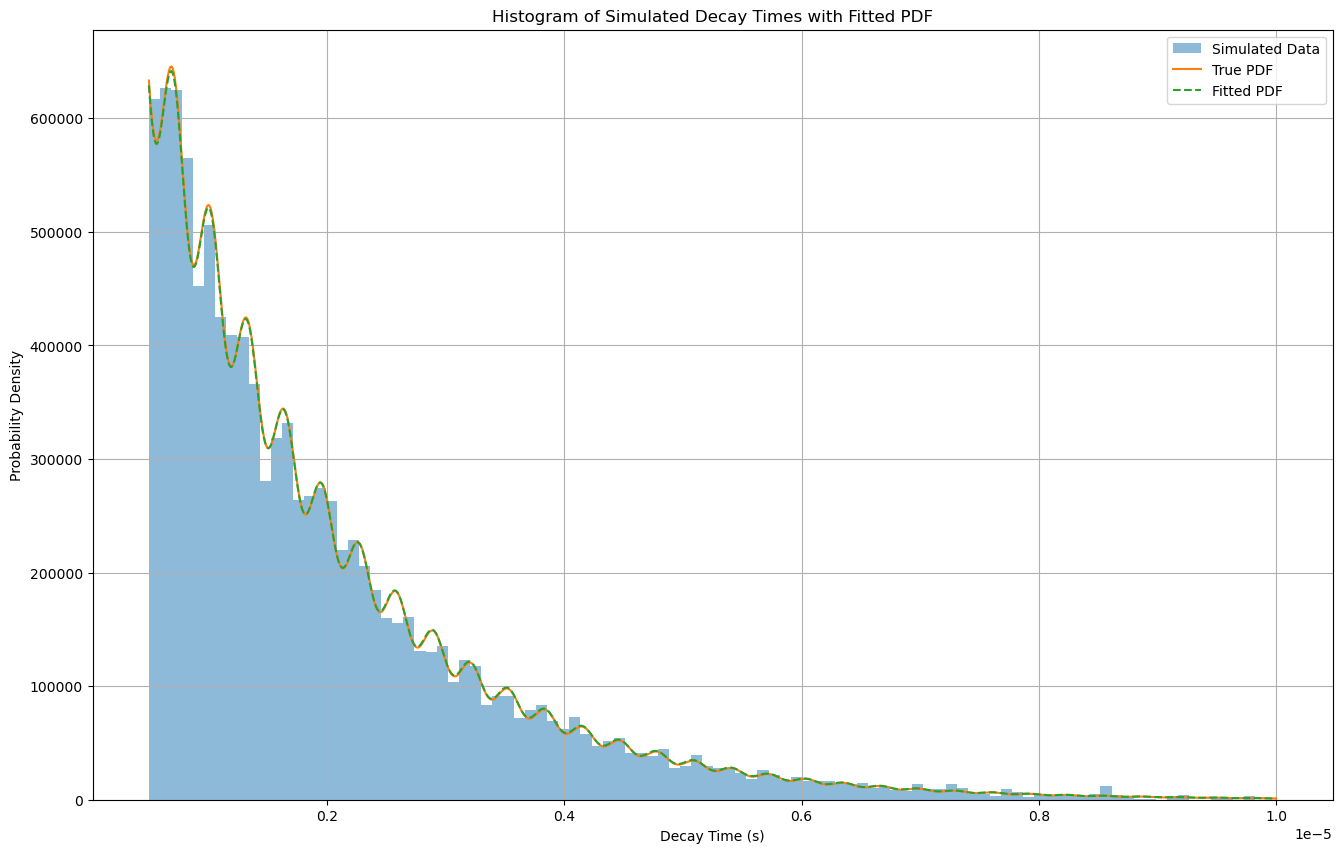

In [9]:
plt.figure(figsize=(16,10))

# Plot the histogram of the simulated data and overlay the true and fitted PDFs
plt.hist(events, bins = 100, density = True, alpha = 0.5, label = 'Simulated Data')
t_plot = np.linspace(t_min, t_max, 1000)
pdf_g = normalized_pdf(t_plot, tau_g, m_g, V_g)
pdf_fit = normalized_pdf(t_plot, tau_fit, m_fit, V_fit)
plt.plot(t_plot, pdf_g, label = 'True PDF')
plt.plot(t_plot, pdf_fit, label = 'Fitted PDF', linestyle = '--')
plt.xlabel('Decay Time (s)')
plt.ylabel('Probability Density')
plt.title('Histogram of Simulated Decay Times with Fitted PDF')
plt.legend()
plt.grid()
plt.show()

Now using pseudoexperiments (100 datasets with 10,000 events each), we look to obtain the statistical precision with which we can measure each of the parameters. This is achieved by iterating over the generation, minimizing, fitting, and recording of the function and parameters 100 times.

* Print statements are outputted to show the progression of the for loop, it was utilized as a reference for the speed of the different event generation methods.

In [10]:
n_experiment = 100

tau_fits = []
tau_errors = []
m_fits = []
m_errors = []
V_fits = []
V_errors = []

for i in range(n_experiment):
    if (i+1) % 25 == 0:
        print(f"Experiment {i+1}/{n_experiment}")

    psuedo_events = generate_events(tau_g, m_g, V_g)
    nll = UnbinnedNLL(psuedo_events, normalized_pdf)
    min = Minuit(nll, tau_g, m_g, V_g)
    min.migrad()
    min.hesse()

    tau_fits.append(min.values['tau'])
    tau_errors.append(min.errors['tau'])
    m_fits.append(min.values['m'])
    m_errors.append(min.errors['m'])
    V_fits.append(min.values['V'])
    V_errors.append(min.errors['V'])

tau_fits = np.array(tau_fits)
tau_errors = np.array(tau_errors)
m_fits = np.array(m_fits)
m_errors = np.array(m_errors)
V_fits = np.array(V_fits)
V_errors = np.array(V_errors)

print(f"Successful fits: {len(tau_fits)}/{n_experiment}")

Experiment 25/100
Experiment 50/100
Experiment 75/100
Experiment 100/100
Successful fits: 100/100


Once each minimized parameter is appended and saved in an array, we calculate the desired statistics with each paramter:
- Mean: $\bar{x} = \Sigma \frac{x_i}{n}$, for $x_i$ parameter and $n$ number of pseudo events.
- Sample Standard deviation: $s = \sqrt{ \frac { \Sigma (x_i - \bar{x})^2}{n-1}} $.
- Bias: $b = \bar{x} - x_{g}$, where $x_{g}$ is the given value of the parameter.
- Estimated Standard Error of the Mean: $ x_{SEM} =  \frac{s}{\sqrt{n}}$
- Precision: $p = b/x_{SEM}$

Note:
* Factors of $\frac{1}{n-1}$ were used instead of $\frac{1}{n}$ in the sample standard deviation to eliminate bias with Bessel's Correction as we use the sample mean rather than the true mean. This is reflected in the calculations below by using a "Delta Degree of Freedom" of ddof = 1 to get $\frac{1}{(n-1)}$ for sample statistics rather than the default ddof = 0 with $\frac{1}{n}$ for population statistics.

* To estimate the standard error of the mean, we use the sample standard deviation as the population mean is unknown.

In [11]:
# Calculate the mean and standard deviation of the fitted parameters (for std use ddof=1)
tau_mean = np.mean(tau_fits)
tau_std = np.std(tau_fits, ddof = 1)
m_mean = np.mean(m_fits)
m_std = np.std(m_fits, ddof = 1)
V_mean = np.mean(V_fits)
V_std = np.std(V_fits, ddof = 1)

#Calculate the bias for each parameter
tau_bias = tau_mean - tau_g
m_bias = m_mean - m_g
V_bias = V_mean - V_g

# Calculate the Standard Error of the Mean (SEM) for each parameter
sem_tau = np.std(tau_fits, ddof = 1) / np.sqrt(len(tau_fits))
sem_m = np.std(m_fits, ddof = 1) / np.sqrt(len(m_fits))
sem_V = np.std(V_fits, ddof = 1) / np.sqrt(len(V_fits))

# Calculate the precision for each parameter
prec_tau = tau_bias/sem_tau
prec_m = m_bias/sem_m
prec_V = V_bias/sem_V

# Create a summary table
stats_table = pd.DataFrame(columns = ['Mean', 'Std', 'Bias', 'SEM', 'Precision'], data = [
    [tau_mean, tau_std, tau_bias, sem_tau, prec_tau],
    [m_mean, m_std, m_bias, sem_m, prec_m],
    [V_mean, V_std, V_bias, sem_V, prec_V]])

# Set the index to parameter names
stats_table.index = ['τ', '∆m', 'V']
stats_table

,Mean,Std,Bias,SEM,Precision
τ,1.502116e-06,1.554489e-08,2.116424e-09,1.554489e-09,1.361491
∆m,2.000112e+07,5.852715e+04,1.120591e+03,5.852715e+03,0.191465
V,1.009081e-01,1.297851e-02,9.080548e-04,1.297851e-03,0.699660


The output values for the bias and precision tell us a lot about fits for each parameter:

-  For τ: The estimator is effectively unbiased as the bias is negligble (~0.06 standard errors from zero). Little offset from the given value as the standard deviation is very small.

- For ∆m: The small bias is not statistically significant, within a $\sigma$. The oscillation frequency appears to be well-constrained with a standard deviation three magnitudes smaller than the mean. 

- For V: The precision shows significance as the mean is ~1.14 standard errors from the true value. Suggests overestimation of the asymmetry paramter.

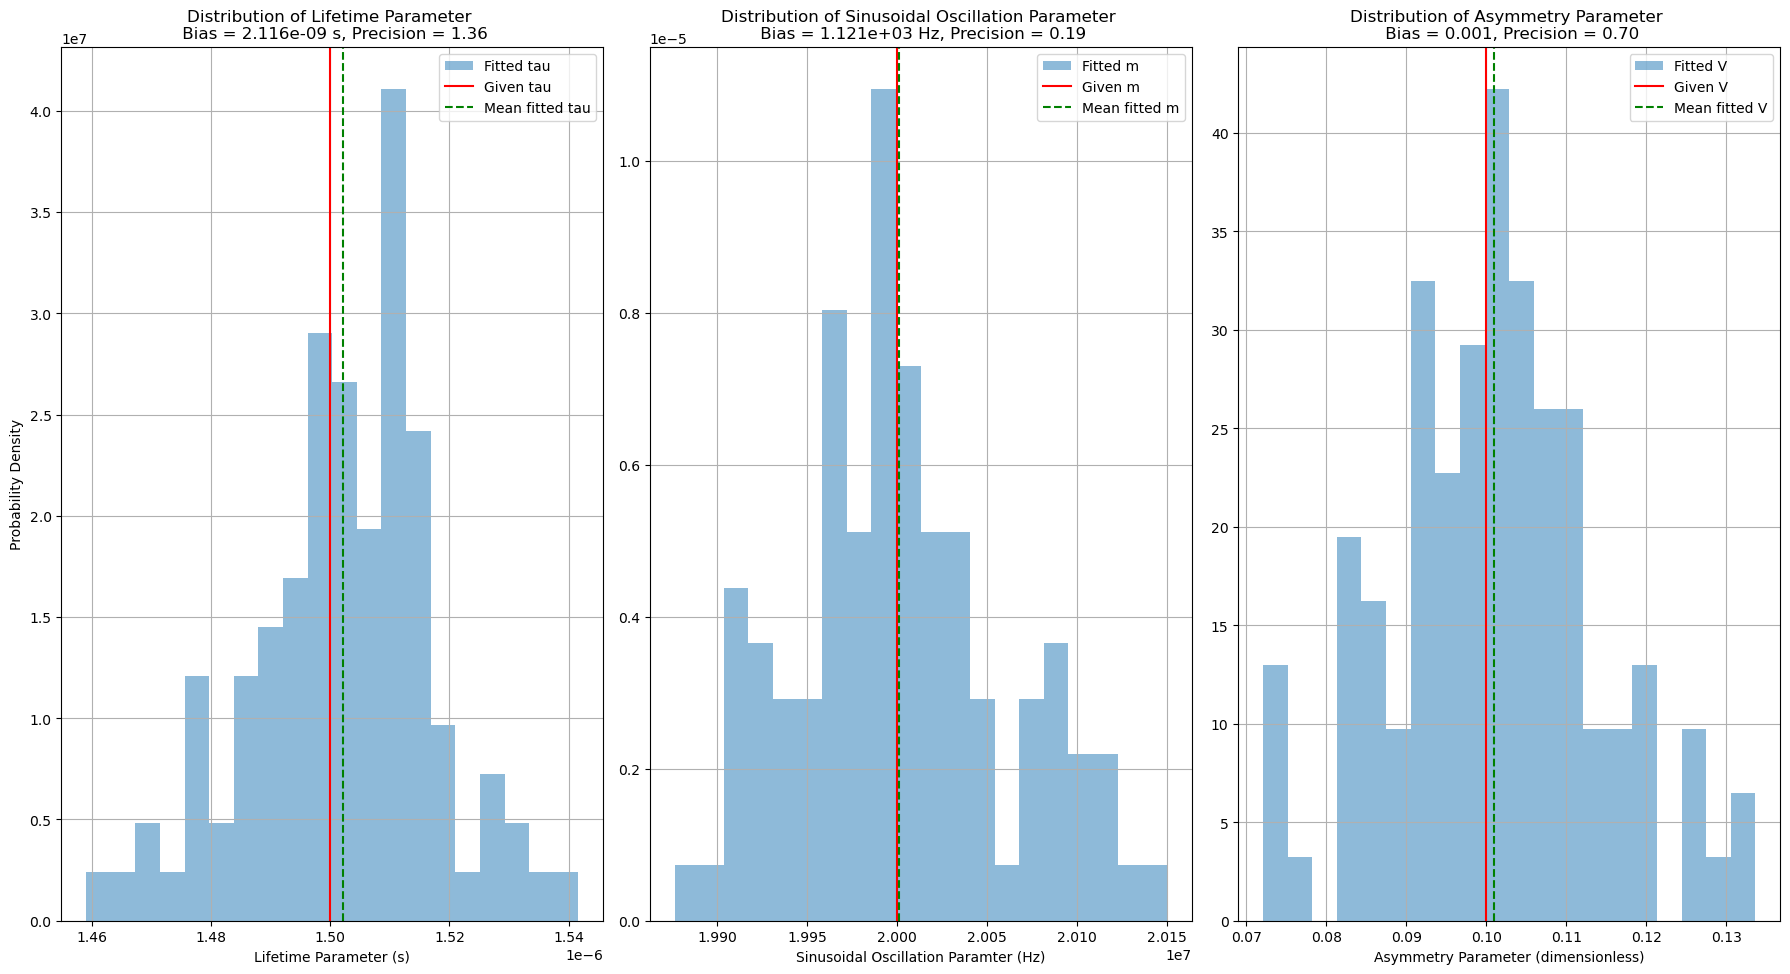

In [12]:
# Plot histograms of the fitted parameters
plt.figure(figsize=(18, 10))

# Lifetime Parameter (tau)
plt.subplot(1,3,1)
plt.hist(tau_fits, bins=20, density=True, alpha=0.5, label='Fitted tau')
plt.axvline(tau_g, color='r', linestyle='-', label='Given tau')
plt.axvline(tau_mean, color='g', linestyle='--', label='Mean fitted tau')
plt.xlabel('Lifetime Parameter (s)')
plt.ylabel('Probability Density')
plt.title(f'Distribution of Lifetime Parameter \n Bias = {tau_bias:.3e} s, Precision = {prec_tau:.2f}')
plt.legend()
plt.grid()

# Sinusoidal Oscillation Parameter (m)
plt.subplot(1,3,2)
plt.hist(m_fits, bins=20, density=True, alpha=0.5, label='Fitted m')
plt.axvline(m_g, color='r', linestyle='-', label='Given m')
plt.axvline(m_mean, color='g', linestyle='--', label='Mean fitted m')
plt.xlabel('Sinusoidal Oscillation Paramter (Hz)')
plt.title(f'Distribution of Sinusoidal Oscillation Parameter \n Bias = {m_bias:.3e} Hz, Precision = {prec_m:.2f}')
plt.legend()
plt.grid()

# Asymmetry Parameter (V)
plt.subplot(1,3,3)
plt.hist(V_fits, bins=20, density=True, alpha=0.5, label='Fitted V')
plt.axvline(V_g, color='r', linestyle='-', label='Given V')
plt.axvline(V_mean, color='g', linestyle='--', label='Mean fitted V')
plt.xlabel('Asymmetry Parameter (dimensionless)')
plt.title(f'Distribution of Asymmetry Parameter \n Bias = {V_bias:.3f}, Precision = {prec_V:.2f}')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()


Plotting the distribution of the fitted parameters highlights the precision and biases with near gaussian distributions across all the parameters. 

In the asymmetry parameter (V), we see the significant deviation in bias with there being an apparent difference between the given and mean values.

The sinusoidal oscillation parameter (∆m) shows the best gaussian distribution with the mean overalpping the given value and tight distribution showing well-constraint fit.

# Step 2

In Step 2, we investigate the inclusion of a background and its effect on the signal. The background pdf is provided below and requires normalization (using the trapezoidal method to reduce runtime). A combined pdf is then produced with a weighted parameter for each individual pdf.

In [13]:
# Background PDF (Gaussian-Like Distribution)

# Sigma value for the background distribution (fixed)
sigma = 0.5e-6 # seconds

def background(t):
    return np.exp(-t**2 / (2*sigma**2)) #Gaussian-Like Distribution
# Looking at the function, it's center is at t=0 with width σ, but we look at the range t_min to t_max.
# Therefore it tail contributes more around t_min and rapidly decreases towards t_max.

#Attempted quad integration, time consuming
# def normalization_background(sigma):
#     integral, _ = quad(background, t_min, t_max, args=(sigma,))
#     return integral

# Normalization of the background using trapezoidal integration
def normalization_background():
    t_vals = np.linspace(t_min, t_max, n)
    bkg_vals = background(t_vals)
    norm = cumulative_trapezoid(bkg_vals, t_vals, initial=0)[-1]
    return norm

# Applies normalization to the background PDF
def normalized_background(t):
    norm = normalization_background()
    return background(t) / norm

# Combined PDF of Signal and Background
def normalized_comb_pdf(t, tau, m, V, f_bkg):
    pdf_sig = normalized_pdf(t, tau, m, V)
    pdf_bkg = normalized_background(t)
    return (1 - f_bkg) * pdf_sig + f_bkg * pdf_bkg

Again, both generation methods were tested; however, the Inverse Cumulative Method was favored for its reliance on a single uniform random number generator to cut down on runtime.

However, in this step, we calculate two datasets, one with just the background (using the normalized background probability density function) and a combined dataset (with the combined normalized probability density function).

In [14]:
#Box Method for event generation with background, slower due to two randomized parameters

# def generate_events_bkg(n_events, tau, m, V, sigma, f_bkg):
#     n_bkg = int(n_events * f_bkg)
#     n_sig = n_events - n_bkg

#     signal_events = []
#     t_test = np.linspace(t_min, t_max, 10000)
#     pdf_sig_max = np.max([normalized_pdf(t, tau, m, V) for t in t_test])

#     while len(signal_events) < n_sig:
#         t_rand = np.random.uniform(t_min, t_max)
#         y_rand = np.random.uniform(0, pdf_sig_max)
#         if y_rand <= normalized_pdf(t_rand, tau, m, V):
#             signal_events.append(t_rand)

#     background_events = []
#     pdf_bkg_max = np.max([normalized_background(t, sigma) for t in t_test])
#     while len(background_events) < n_bkg:
#         t_rand = np.random.uniform(t_min, t_max)
#         y_rand = np.random.uniform(0, pdf_bkg_max)
#         if y_rand <= normalized_background(t_rand, sigma):
#             background_events.append(t_rand)

#     all_events = np.array(signal_events + background_events)
#     return all_events

In [15]:
# CDF and PPF for the background distribution
def cdf_bkg(t_min, t_max):
    
    # Creates an array of time values and computes the background PDF at those points
    t_vals = np.linspace(t_min, t_max, n)
    pdf_vals = normalized_background(t_vals)

    # Computes the CDF using trapezoidal integration
    cdf_vals = cumulative_trapezoid(pdf_vals, t_vals, initial=0)
    cdf_vals = cdf_vals / cdf_vals[-1]  # Normalize CDF

    # Interpolates the CDF at each value within the range to create the PPF
    ppf = interpolate.interp1d(cdf_vals, t_vals,  fill_value=(t_min, t_max))

    return ppf

# Generates events for signal and background using their respective PPFs
def generate_events_bkg(tau, m, V, f_bkg):
    # Determine number of background and signal events
    n_bkg = int(f_bkg * n)
    n_sig = n - n_bkg

    # Get PPFs for signal and background
    ppf_bkg = cdf_bkg(t_min, t_max)
    ppf_sig = cdf(tau, m, V, t_min, t_max)

    # Random uniform values for signal and background
    u_sig = np.random.uniform(0, 1, n_sig)
    sig_event = ppf_sig(u_sig)

    u_bkg = np.random.uniform(0, 1, n_bkg)
    bkg_event = ppf_bkg(u_bkg)

    # Combine signal and background events
    all_events = np.concatenate((sig_event, bkg_event))

    return all_events

Plotting the distribution functions with outlines showing the signal, background, and combination of the two density functions across three different given weighted parameters (1% background contribution, 10% background contribution, and 20% background contribution).

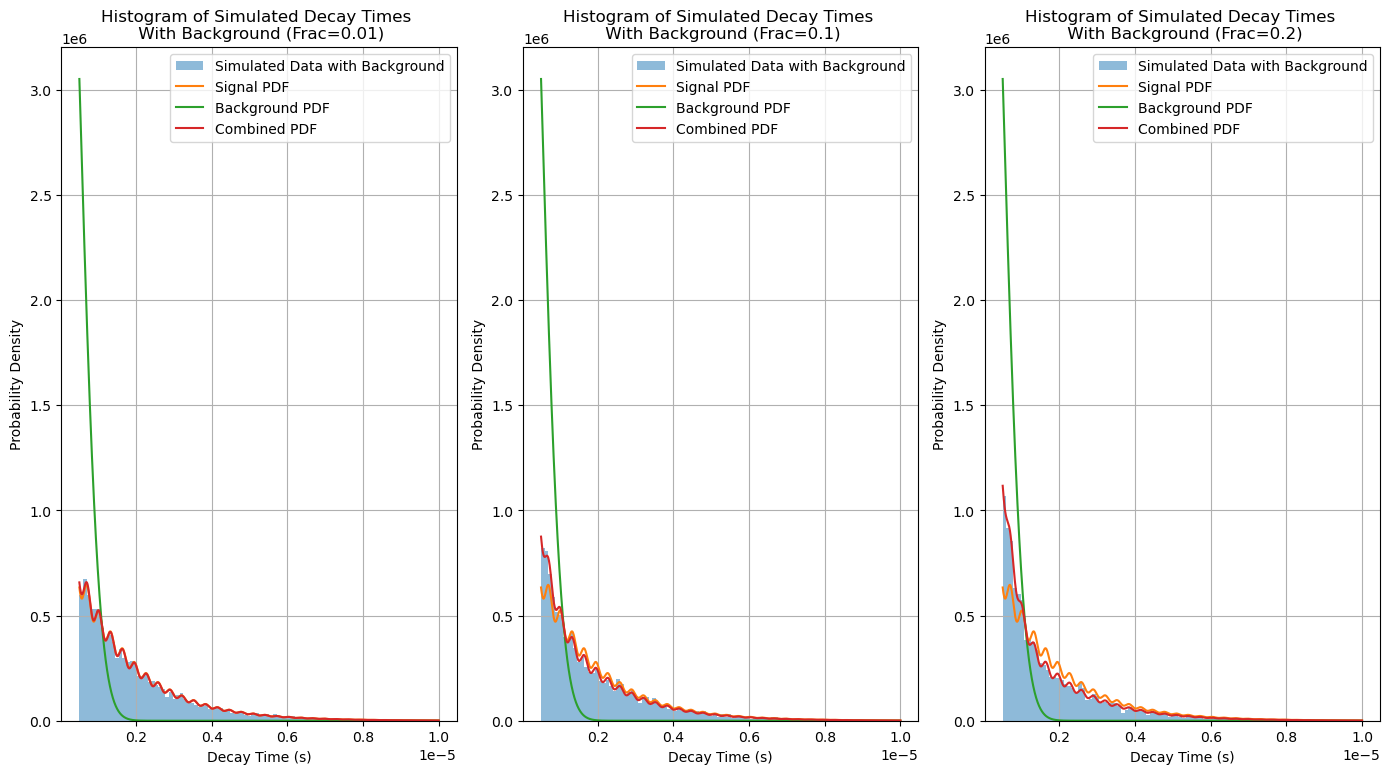

In [16]:
# Plotting histograms for different background fractions
plt.figure(figsize=(14, 8))
f_bkg = [0.01, 0.10, 0.20]

# Loop over different background fractions and plot histograms
for i, f_bkg in enumerate(f_bkg):
    events_bg = generate_events_bkg(tau_g, m_g, V_g, f_bkg)

    # Create subplot for each background fraction
    plt.subplot(1, 3, i+1)
    plt.hist(events_bg, bins=100, density=True, alpha=0.5, label= f'Simulated Data with Background')
    t_plot = np.linspace(t_min, t_max, 1000)
    pdf_sig = normalized_pdf(t_plot, tau_g, m_g, V_g)
    pdf_bkg = normalized_background(t_plot)
    pdf_combined = (1 - f_bkg) * pdf_sig + f_bkg * pdf_bkg

    # Plot signal, background, and combined PDFs
    plt.plot(t_plot, pdf_sig, label='Signal PDF')
    plt.plot(t_plot, pdf_bkg, label='Background PDF')
    plt.plot(t_plot, pdf_combined, label= 'Combined PDF')

    plt.xlabel('Decay Time (s)')
    plt.ylabel('Probability Density')
    plt.title(f'Histogram of Simulated Decay Times \n With Background (Frac={f_bkg})')
    plt.legend()
    plt.grid()

plt.tight_layout()
plt.show()


As to be expected, for the 1% background contribution, the combined distributions doesn't observably deviate from the signal.

For the 10% and 20% we start to see noticeable divergence between the distribution functions, with the most significant occurring where the background is largest ~ < 0.2e-4 (s) of Decay Time.

Now iterating over 100 pseudoexperiments for each of the different initial weighted parameters. We want to compare it to the results where the background is absent. Therefore, we again generate datasets, minimize, and fit for both distributions.

In [17]:
# Run 100 pseudo-experiments for each background fraction
n_experiment = 100
f_bkg = [0.01, 0.10, 0.20]

# Dictionaries to store results
results_sig = {}
results_mix = {}

# Loop over each background fraction
for frac in f_bkg:

    # Lists to store fit results for signal only and signal + background
    tau_fits = []
    tau_errors = []
    m_fits = []
    m_errors = []
    V_fits = []
    V_errors = []
    f_fits = []
    f_errors = []

    tau_fits_mix = []
    tau_errors_mix = []
    m_fits_mix= []
    m_errors_mix = []
    V_fits_mix = []
    V_errors_mix = []
    f_fits_mix = []
    f_errors_mix = []


    for i in range(n_experiment):
        if (i+1) % 25 == 0:
            print(f"Experiment {i+1}/{n_experiment} for Fraction = {frac * 100}%")

        # Generate pseudo-events with the specified background fraction
        pseudo_events_mix = generate_events_bkg(tau_g, m_g, V_g, frac)

        # Fit signal only model
        nll_sig = UnbinnedNLL(pseudo_events_mix, normalized_pdf)
        min_sig = Minuit(nll_sig, tau_g, m_g, V_g)
        min_sig.migrad()


        # Store fit results for signal only
        tau_fits.append(min_sig.values['tau'])
        tau_errors.append(min_sig.errors['tau'])
        m_fits.append(min_sig.values['m'])
        m_errors.append(min_sig.errors['m'])
        V_fits.append(min_sig.values['V'])
        V_errors.append(min_sig.errors['V'])


        # Fit signal + background model
        nll_bkg = UnbinnedNLL(pseudo_events_mix, normalized_comb_pdf)
        min_bkg = Minuit(nll_bkg, tau_g, m_g, V_g, frac)
        min_bkg.migrad()


        # Store fit results for signal + background
        tau_fits_mix.append(min_bkg.values['tau'])
        tau_errors_mix.append(min_bkg.errors['tau'])
        m_fits_mix.append(min_bkg.values['m'])
        m_errors_mix.append(min_bkg.errors['m'])
        V_fits_mix.append(min_bkg.values['V'])
        V_errors_mix.append(min_bkg.errors['V'])
        f_fits_mix.append(min_bkg.values['f_bkg'])
        f_errors_mix.append(min_bkg.errors['f_bkg'])


    # Store results in dictionaries
    results_sig[frac] = {
        'tau_fits': np.array(tau_fits),
        'tau_errors': np.array(tau_errors),
        'm_fits': np.array(m_fits),
        'm_errors': np.array(m_errors),
        'V_fits': np.array(V_fits),
        'V_errors': np.array(V_errors)
    }

    results_mix[frac] = {
        'tau_fits': np.array(tau_fits_mix),
        'tau_errors': np.array(tau_errors_mix),
        'm_fits': np.array(m_fits_mix),
        'm_errors': np.array(m_errors_mix),
        'V_fits': np.array(V_fits_mix),
        'V_errors': np.array(V_errors_mix),
        'f_bkg_fits': np.array(f_fits_mix),
        'f_bkg_errors': np.array(f_errors_mix)
    }

Experiment 25/100 for Fraction = 1.0%
Experiment 50/100 for Fraction = 1.0%
Experiment 75/100 for Fraction = 1.0%
Experiment 100/100 for Fraction = 1.0%
Experiment 25/100 for Fraction = 10.0%
Experiment 50/100 for Fraction = 10.0%
Experiment 75/100 for Fraction = 10.0%
Experiment 100/100 for Fraction = 10.0%
Experiment 25/100 for Fraction = 20.0%
Experiment 50/100 for Fraction = 20.0%
Experiment 75/100 for Fraction = 20.0%
Experiment 100/100 for Fraction = 20.0%


Once each minimized paramter is appended, we again calculate the statistics (mean, bias, sample standard deviation, estimated standard error of the mean, and precision) across all three given weighted parameters.

The calculations use the same framework as those in step one, with sample unbiased statistics with Bessel's Correction.

- Mean: $\bar{x} = \Sigma \frac{x_i}{n}$, for $x_i$ parameter and $n$ number of pseudo events.
- Sample Standard deviation: $s = \sqrt{ \frac { \Sigma (x_i - \bar{x})^2}{n-1}} $.
- Bias: $b = \bar{x} - x_{g}$, where $x_{g}$ is the given value of the parameter.
- Estimated Standard Error of the Mean: $ x_{SEM} =  \frac{s}{\sqrt{n}}$
- Precision: $p = b/x_{SEM}$


In [18]:
# For each background fraction, calculate and display statistics
for frac in f_bkg:
    data_sig = results_sig[frac]
    data_mix = results_mix[frac]

    # Calculate the statistics for signal only fits
    tau_mean_sig = np.mean(data_sig['tau_fits'])
    tau_bias_sig = tau_mean_sig - tau_g
    tau_std_sig = np.std(data_sig['tau_fits'], ddof = 1)
    tau_sem_sig = tau_std_sig / np.sqrt(len(data_sig['tau_fits']))
    tau_prec_sig = tau_bias_sig / tau_sem_sig

    m_mean_sig = np.mean(data_sig['m_fits'])
    m_bias_sig = m_mean_sig - m_g
    m_std_sig = np.std(data_sig['m_fits'], ddof = 1)
    m_sem_sig = m_std_sig / np.sqrt(len(data_sig['m_fits']))
    m_prec_sig = m_bias_sig / m_sem_sig

    V_mean_sig = np.mean(data_sig['V_fits'])
    V_bias_sig = V_mean_sig - V_g
    V_std_sig = np.std(data_sig['V_fits'], ddof = 1)
    V_sem_sig = V_std_sig / np.sqrt(len(data_sig['V_fits']))
    V_prec_sig = V_bias_sig / V_sem_sig

    # Calculate the statistics for signal + background fits
    tau_mean_mix = np.mean(data_mix['tau_fits'])
    tau_bias_mix = tau_mean_mix - tau_g
    tau_std_mix = np.std(data_mix['tau_fits'], ddof = 1)
    tau_sem_mix = tau_std_mix / np.sqrt(len(data_mix['tau_fits']))
    tau_prec_mix = tau_bias_mix / tau_sem_mix

    m_mean_mix = np.mean(data_mix['m_fits'])
    m_bias_mix = m_mean_mix - m_g
    m_std_mix = np.std(data_mix['m_fits'], ddof = 1)
    m_sem_mix = m_std_mix / np.sqrt(len(data_mix['m_fits']))
    m_prec_mix = m_bias_mix / m_sem_mix

    V_mean_mix = np.mean(data_mix['V_fits'])
    V_bias_mix = V_mean_mix - V_g
    V_std_mix = np.std(data_mix['V_fits'], ddof = 1)
    V_sem_mix = V_std_mix / np.sqrt(len(data_mix['V_fits']))
    V_prec_mix = V_bias_mix / V_sem_mix

    # Statistics for the fitted background fraction
    frac_mean_mix = np.mean(data_mix['f_bkg_fits'])
    frac_bias_mix = frac_mean_mix - frac
    frac_std_mix = np.std(data_mix['f_bkg_fits'], ddof = 1)
    frac_sem_mix = frac_std_mix / np.sqrt(len(data_mix['f_bkg_fits']))
    frac_prec_mix = frac_bias_mix / frac_sem_mix
    
    # Creates the summary table
    df = pd.DataFrame({
        ('', 'Signal Only', 'τ'): [f'{tau_mean_sig:.3e}',  f'{tau_bias_sig:.3e}',  f'{tau_prec_sig:.3f}'],
        ('', 'Signal Only', '∆m'): [f'{m_mean_sig:.3e}', f'{m_bias_sig:.3e}',  f'{m_prec_sig:.3f}'],
        ('', 'Signal Only', 'V'): [f'{V_mean_sig:.3f}',  f'{V_bias_sig:.3f}', f'{V_prec_sig:.3f}'],

        (f'Fraction = {frac * 100}%', 'With Background', 'τ'): [f'{tau_mean_mix:.3e}', f'{tau_bias_mix:.3e}',f'{tau_prec_mix:.3f}'],
        (f'Fraction = {frac * 100}%', 'With Background', '∆m'): [f'{m_mean_mix:.3e}',  f'{m_bias_mix:.3e}',  f'{m_prec_mix:.3f}'],
        (f'Fraction = {frac * 100}%', 'With Background', 'V'): [f'{V_mean_mix:.3f}',  f'{V_bias_mix:.3f}',  f'{V_prec_mix:.3f}'],
        (f'Fraction = {frac * 100}%', 'With Background', 'f_bkg'): [f'{frac_mean_mix:.3f}', f'{frac_bias_mix:.3f}', f'{frac_prec_mix:.3f}'],

        ('', 'Difference (Comb. - Sig.)', 'τ'): [f'{tau_mean_sig - tau_mean_mix:.3e}', f'{tau_bias_sig - tau_bias_mix:.3e}',  f'{tau_prec_sig - tau_prec_mix:.3f}'],
        ('', 'Difference (Comb. - Sig.)', '∆m'): [f'{m_mean_sig - m_mean_mix:.3e}',  f'{m_bias_sig - m_bias_mix:.3e}', f'{m_prec_sig - m_prec_mix:.3f}'],
        ('', 'Difference (Comb. - Sig.)', 'V'): [f'{V_mean_sig - V_mean_mix:.3f}', f'{V_bias_sig - V_bias_mix:.3f}', f'{V_prec_sig - V_prec_mix:.3f}'],
    }, index = ['Mean', 'Bias', 'Precision'])

    display(df)


Fraction = 1.0%                      \
          Signal Only                     With Background                       
                    τ          ∆m       V               τ          ∆m       V   
Mean        1.485e-06   2.000e+07   0.097       1.499e-06   2.000e+07   0.100   
Bias       -1.491e-08  -3.706e+03  -0.003      -8.906e-10  -4.574e+03  -0.000   
Precision     -10.712      -0.634  -2.333          -0.537      -0.785  -0.153   

                                                               
                 Difference (Comb. - Sig.)                     
           f_bkg                         τ         ∆m       V  
Mean       0.011                -1.402e-08  8.676e+02  -0.003  
Bias       0.001                -1.402e-08  8.676e+02  -0.003  
Precision  0.906                   -10.176      0.151  -2.180

Fraction = 10.0%                    \
          Signal Only                      With Background                     
                    τ         ∆m        V                τ         ∆m      V   
Mean        1.371e-06  2.001e+07    0.076        1.499e-06  2.000e+07  0.103   
Bias       -1.295e-07  1.215e+04   -0.024       -1.450e-09  3.800e+03  0.003   
Precision     -85.276      1.728  -17.572           -0.692      0.546  1.688   

                                                                 
                  Difference (Comb. - Sig.)                      
            f_bkg                         τ         ∆m        V  
Mean        0.099                -1.280e-07  8.348e+03   -0.026  
Bias       -0.001                -1.280e-07  8.348e+03   -0.026  
Precision  -0.798                   -84.584      1.182  -19.261

Fraction = 20.0%              \
          Signal Only                      With Background               
                    τ         ∆m        V                τ          ∆m   
Mean        1.245e-06  2.001e+07    0.048        1.500e-06   1.999e+07   
Bias       -2.546e-07  5.749e+03   -0.052        4.461e-10  -1.411e+04   
Precision    -193.698      0.738  -35.426            0.191      -1.862   

                                                                         
                          Difference (Comb. - Sig.)                      
                V   f_bkg                         τ         ∆m        V  
Mean        0.099   0.200                -2.551e-07  1.986e+04   -0.051  
Bias       -0.001  -0.000                -2.551e-07  1.986e+04   -0.051  
Precision  -0.492  -0.269                  -193.889      2.600  -34.934

Looking at the difference at the statistical calculations, we see significant trends for the signal only parameters.

For the lifetime parameter (τ): The increasing underestimation occurs due to the gaussian background peaking decay time ~ $t_{min}$. This is the intepreted as faster exponential decay in the signal only fit. Resulting in a systematic bias of the lifetime parameter as τ is pulled fruther from the true value.

For the sinusoidal oscillation parameter (∆m): Less background influence as the oscillations are still prominent at later decay times where the background becomes suppressed. However, as the weighted fraction of the background increases, there is more distortion in the early oscillation structure and more bias.

For the aysmmetry parameter (V): The background influences the oscillatory amplitude, causing the fit to intepret the loss of oscillatory visibility as lower asymmetry. This is shown through the increasing underestimate of the parameter as the amount of background increases.

The reason why this occurs is because we fit the signal only model using the generation that contains both the background and signal functions. Since the model doesn't include the background component, there is systematic bias. That is why the magnitude of the precisions for the signal only parameters increase as the background component of the event generation gets more significant. This is done so that we can show that ignoring the background leads to systematic biases where the precision degrades. Where as accounting background in the fit maintains the precision. Therefore, you can't just ignore background with contaminated data (where the background is used to generate the events).

Regarding the combined model (with background), the precisions all lie ~$2\sigma$ from zero. The lifetime parameter (τ) and the sinusoidal oscillation paramter (∆m) show no systematic trend with background fraction and with negligble bias. A noticable trend can be found with the asymmetry parameter, where although the bias remains constant, the precision increases as the fraction of the background increases. This can suggest subtle correlation between the it and the fraction of the background contribution. The fit for the background fraction correctly estimates the true values with all precisions equaling $ < 1\sigma$.

Therefore, including the background as a free parameter eliminates the systematic biases with the likelihood correctly seperating the signal and background contributions.

Plotting of the distributions using GridSpec to design a 3x4 grid of plots for the different parameters at different weighted fractions. Gridspec utilizes an extra row and column to display the legend and labels.

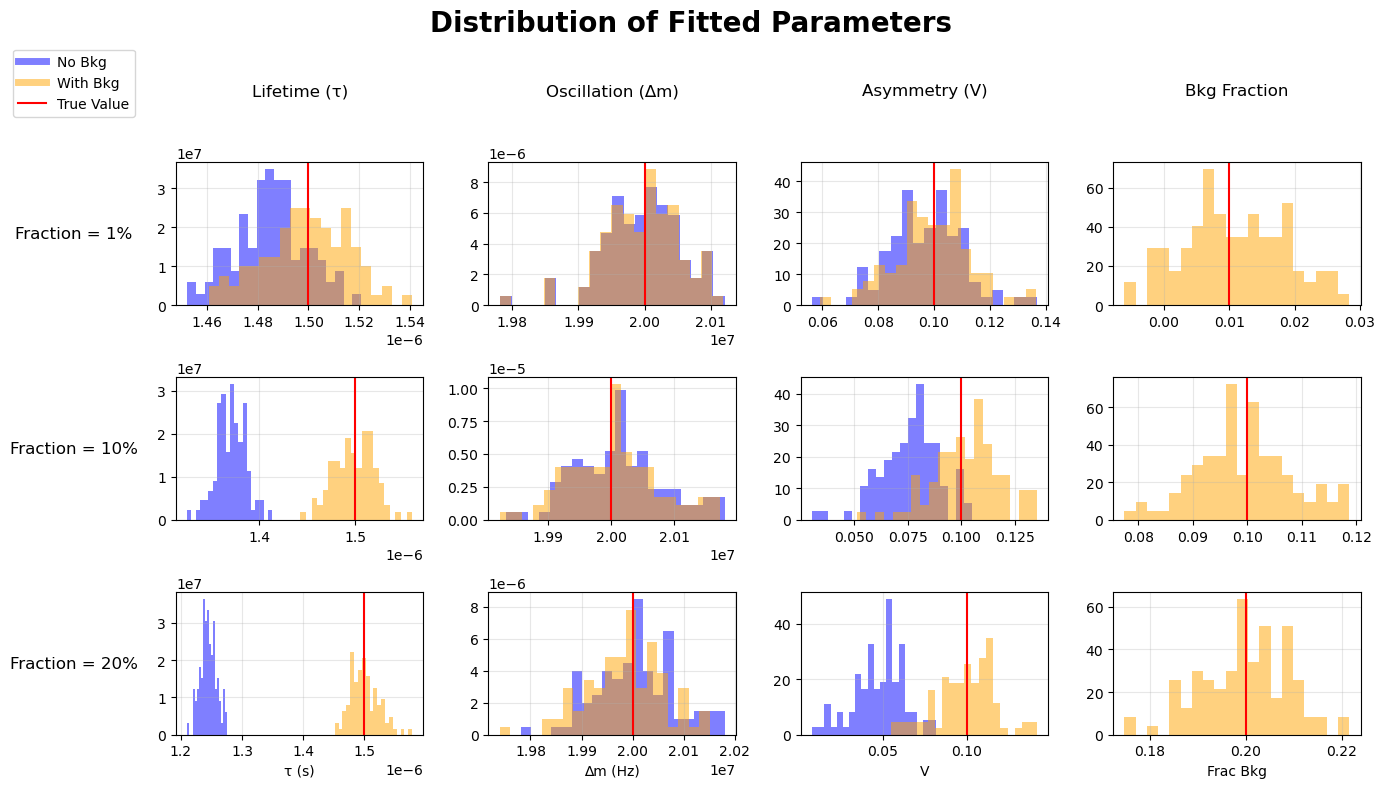

In [19]:
def distributions():
    # Create a figure with a grid layout
    fig = plt.figure(figsize=(14, 8))
    # Define the grid layout, adds a row and column for labels with smaller width/height
    gs = GridSpec(len(f_bkg) + 1, 5, figure=fig, width_ratios=[0.3, 1, 1, 1, 1], height_ratios=[0.10, 1, 1, 1]) 
    
    # Title for the entire figure
    fig.suptitle('Distribution of Fitted Parameters', fontsize=20, fontweight = 'bold')

    # Column headers
    param_names = ['Lifetime (τ)', 'Oscillation (∆m)', 'Asymmetry (V)', 'Bkg Fraction']
    for j, name in enumerate(param_names):
        fig.add_subplot(gs[0, j + 1])
        plt.text(0.5, 0.5, name, ha='center', va='top', fontsize=12)
        plt.axis('off')
    
    # Plot each parameter for each f_bkg value
    for i, frac in enumerate(f_bkg):
        plt_label = fig.add_subplot(gs[i + 1, 0])
        plt_label.text(0.5, 0.5, f'Fraction = {frac*100:.0f}%', ha='center', va='center', fontsize=12)
        plt_label.axis('off')
        
        # Extract data for current background fraction
        data_no_bkg = results_sig[frac]
        data_with_bkg = results_mix[frac]
        
        # tau - subplot 1
        sub1 = fig.add_subplot(gs[i + 1, 1])
        plt.hist(data_no_bkg['tau_fits'], bins=20, density=True, alpha=0.5, color='blue')
        plt.hist(data_with_bkg['tau_fits'], bins=20, density=True, alpha=0.5, color='orange')
        plt.axvline(tau_g, color='r', linestyle='-')
        plt.grid(True, alpha=0.3)
        # Only set xlabel for the bottom row
        if i == len(f_bkg) - 1:
            sub1.set_xlabel('τ (s)')
        
        # m - subplot 2
        sub2 = fig.add_subplot(gs[i + 1, 2])
        plt.hist(data_no_bkg['m_fits'], bins=20, density=True, alpha=0.5, color='blue')
        plt.hist(data_with_bkg['m_fits'], bins=20, density=True, alpha=0.5, color='orange')
        plt.axvline(m_g, color='r', linestyle='-')
        plt.grid(True, alpha=0.3)
        if i == len(f_bkg) - 1:
            sub2.set_xlabel('∆m (Hz)')
        
        # V - subplot 3
        sub3 = fig.add_subplot(gs[i + 1, 3])
        plt.hist(data_no_bkg['V_fits'], bins=20, density=True, alpha=0.5, color='blue')
        plt.hist(data_with_bkg['V_fits'], bins=20, density=True, alpha=0.5, color='orange')
        plt.axvline(V_g, color='r', linestyle='-')
        plt.grid(True, alpha=0.3)
        if i == len(f_bkg) - 1:
            sub3.set_xlabel('V')
        
        # f_bkg - subplot 4
        sub4 = fig.add_subplot(gs[i + 1, 4])
        plt.hist(data_with_bkg['f_bkg_fits'], bins=20, density=True, alpha=0.5, color='orange')
        plt.axvline(frac, color='r', linestyle='-')
        plt.grid(True, alpha=0.3)
        if i == len(f_bkg) - 1:
            sub4.set_xlabel('Frac Bkg')
    
    #Legend
    legend = fig.add_subplot(gs[0, 0])
    # Uses empty plots '[]' to create custom legend entries
    legend.plot([], [], color='blue', alpha=0.5, linewidth=5, label='No Bkg')
    legend.plot([], [], color='orange', alpha=0.5, linewidth=5, label='With Bkg')
    legend.plot([], [], color='red', linestyle='-', label='True Value')
    legend.legend(loc='center', fontsize=10)
    legend.axis('off')
    
    plt.tight_layout()
    return fig

plot_fig = distributions()
plt.show()

As depicted in the statistical calculations, the lifetime parameter (τ) highlights the largest systematic bias where the model is significantly underestimated. In contrast, the mixed model (with background) maintains a distribution around the true value.

The sinusoidal oscillation parameter (∆m) remains robust to the background influence across both models. As described in the statistics, when the background becomes more prominent it is suppressed. This is because the oscillations persist for longer decay times, as the spacing between the peaks/troughs are maintained even when the overall amplitude is affected by the background..

Like the lifetime parameter, the asymmetry parameter gets more underestimated as the fraction of background increases. This is due to the amplitude of the sinusoidal oscillations decreases with more background; therefore, less sinusoidal behavior is reflected in a smaller asymmetry by the fit.

The distribution of the background fractions is only applicable in the case where the model accounts for background. Each distribution maintains a fit around the true value with negligble bias. There is a trend in the width of the distribution, getting larger with the background fraction, and this is due to a decrease in the signal-to-background ratio.

Overall the combined model with signal and background remain centered around the true values across all parameters and background fractions, showcasing the need to properly model backgrounds for unbiased estimations.